# Logistic Regression 1 - Theory Made Simple

> **MLCourse · Machine Learning · 02_logistic_regression**

Classification with the SAME engine you already mastered: a weighted sum,
one new S-shaped squashing function, and the identical gradient-descent update.
No derivation walls - just pictures, probabilities, and plain language.

### What you'll learn
- Why linear regression can't predict categories - and what to do instead
- Probability → odds → **log-odds** (the secret of the name "regression")
- The sigmoid: one curve that turns any number into a probability
- A loss function built from common sense: *punish confident wrong answers*
- The gradient - same shape as linear regression's, revealed not derived
- When to choose logistic regression

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def load(name):
    try:
        return sns.load_dataset(name)
    except Exception as e:
        print(f"offline? ({e})")
        return pd.DataFrame()

tips = load("tips")

### 1. Why not just use linear regression?

Suppose we want YES/NO answers: survived? spam? sick?
Linear regression outputs ANY number (-3.7, 12.4...) - meaningless for a yes/no.

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_54936\2426526336.py:25: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


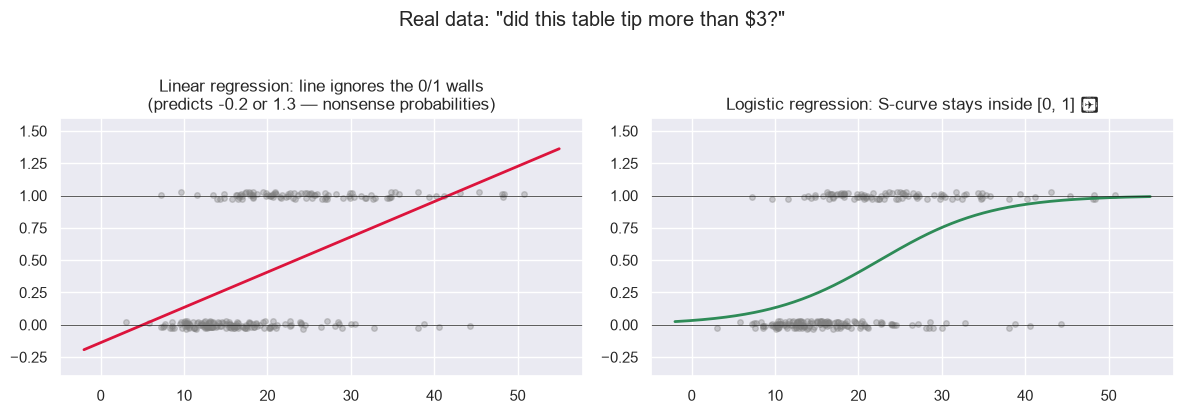

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Real data: does bill size relate to being a "big tipper" (> $3)?
big_tip = (tips["tip"] > 3).astype(int)          # 1 = yes, 0 = no
X = tips[["total_bill"]].values

lin = LinearRegression().fit(X, big_tip)
xs = np.linspace(-2, 55, 300).reshape(-1, 1)

axes[0].scatter(tips.total_bill, big_tip + np.random.uniform(-.03, .03, len(big_tip)),
                s=16, alpha=.35, color="gray")
axes[0].plot(xs, lin.predict(xs), color="crimson", lw=2)
axes[0].set_ylim(-0.4, 1.6); axes[0].axhline(0, c="k", lw=.5); axes[0].axhline(1, c="k", lw=.5)
axes[0].set_title("Linear regression: line ignores the 0/1 walls\n"
                  "(predicts -0.2 or 1.3 - nonsense probabilities)")

logr = LogisticRegression().fit(X, big_tip)
axes[1].scatter(tips.total_bill, big_tip + np.random.uniform(-.03, .03, len(big_tip)),
                s=16, alpha=.35, color="gray")
axes[1].plot(xs, logr.predict_proba(xs)[:, 1], color="seagreen", lw=2)
axes[1].set_ylim(-0.4, 1.6); axes[1].axhline(0, c="k", lw=.5); axes[1].axhline(1, c="k", lw=.5)
axes[1].set_title("Logistic regression: S-curve stays inside [0, 1] ✓")

plt.suptitle('Real data: "did this table tip more than $3?"', y=1.03)
plt.tight_layout(); plt.show()

### 2. Probability → odds → log-odds (three friendly steps)

| Concept | Formula | Example (p = 0.8) |
|---|---|---|
| probability | $p \in [0,1]$ | 0.8 |
| odds | $\frac{p}{1-p}$ ("wins per loss") | 4 : 1 |
| log-odds | $\ln\frac{p}{1-p}$ | +1.39 |

The magic: log-odds can be ANY number (-∞ to +∞). That's exactly what a linear
equation produces! So:

$$\underbrace{\ln\frac{p}{1-p}}_{\text{any number}} = w_0 + w_1x_1+\cdots+w_nx_n$$

…and THAT is why the word "regression" appears in the name - the right-hand side
is our old friend, the weighted sum.

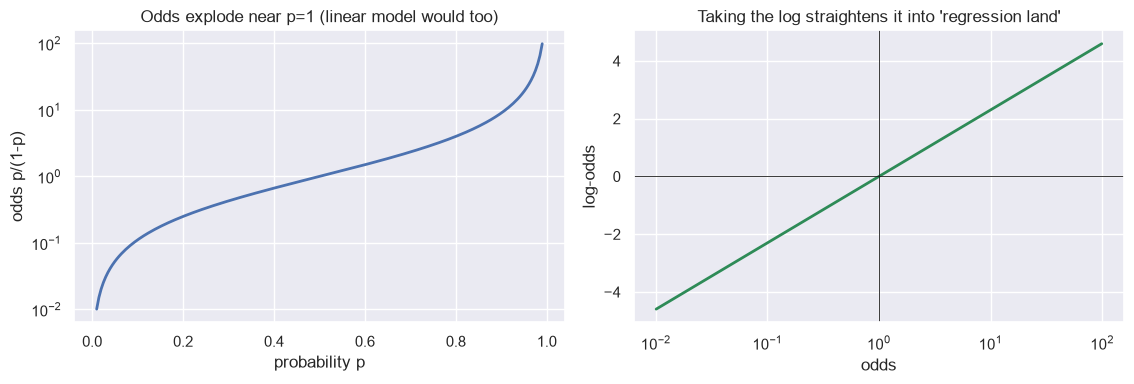

In [3]:
p_grid = np.linspace(0.01, 0.99, 200)
odds = p_grid / (1 - p_grid)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(p_grid, odds, lw=2)
axes[0].set_yscale("log"); axes[0].set_xlabel("probability p"); axes[0].set_ylabel("odds p/(1-p)")
axes[0].set_title("Odds explode near p=1 (linear model would too)")
axes[1].plot(odds, np.log(odds), lw=2, color="seagreen")
axes[1].axhline(0, c="k", lw=.6); axes[1].axvline(1, c="k", lw=.6)
axes[1].set_xscale("log"); axes[1].set_xlabel("odds"); axes[1].set_ylabel("log-odds")
axes[1].set_title("Taking the log straightens it into 'regression land'")
plt.tight_layout(); plt.show()

### 3. The sigmoid - one curve to remember

We need to UNDO the log-odds transform: given a linear score $z$, get back a
probability. That inverse is the **sigmoid**:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

Properties you only need to FEEL:
- $z=0 \Rightarrow p=0.5$ (perfect coin flip)
- big positive $z$ → p hugs 1; big negative → p hugs 0
- output ALWAYS inside (0, 1) - a legal probability

D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


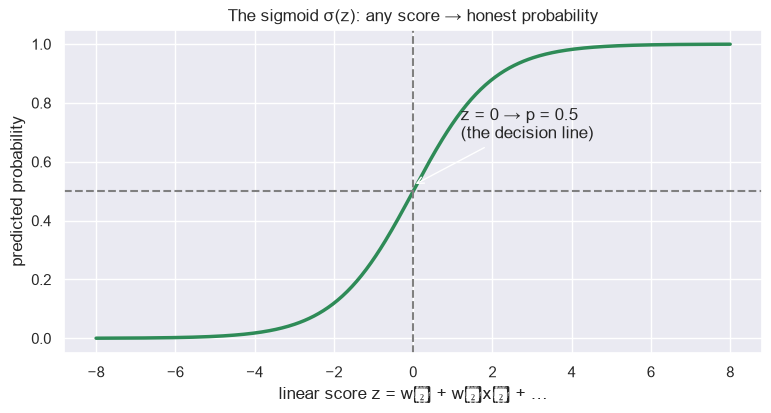

sanity checks:
  z=-4  ->  σ=0.0180
  z=-1  ->  σ=0.2689
  z=+0  ->  σ=0.5000
  z=+1  ->  σ=0.7311
  z=+4  ->  σ=0.9820


In [4]:
z = np.linspace(-8, 8, 400)
plt.figure(figsize=(9, 4.2))
plt.plot(z, 1/(1+np.exp(-z)), lw=2.5, color="seagreen")
plt.axvline(0, ls="--", c="gray"); plt.axhline(.5, ls="--", c="gray")
plt.annotate("z = 0 → p = 0.5\n(the decision line)", (0, .52), xytext=(1.2, .68),
             arrowprops=dict(arrowstyle="->"))
plt.title("The sigmoid σ(z): any score → honest probability")
plt.xlabel("linear score z = w₀ + w₁x₁ + …"); plt.ylabel("predicted probability")
plt.show()

print("sanity checks:")
for zz in [-4, -1, 0, 1, 4]:
    print(f"  z={zz:+d}  ->  σ={1/(1+np.exp(-zz)):.4f}")

### 4. The full model in one box

$$p(\text{class}=1 \mid x) = \sigma(w_0 + w_1x_1 + \cdots + w_nx_n)$$

Decision rule: predict class 1 when $p \ge 0.5$ - i.e. when the LINEAR SCORE
is ≥ 0. (We'll move that threshold deliberately in notebook 04.)

### 5. Loss built from common sense

What should a good model pay for its mistakes?

- Truth = 1, model says p = 0.99 → tiny cost ✓
- Truth = 1, model says p = 0.60 → some cost
- Truth = 1, model CONFIDENTLY says p = 0.01 → huge cost!

The function that does exactly this is **-log(p)** (cost explodes as p → 0).
For truth = 0, mirror it: -log(1-p). Combine both cases:

$$\text{loss}(y, p) = -\big[y\log(p) + (1-y)\log(1-p)\big]
\qquad\qquad J = \frac{1}{m}\sum_i \text{loss}(y^{(i)}, p^{(i)})$$

One formula, no case-splitting needed - because y is 0 or 1, exactly one term
survives each time.

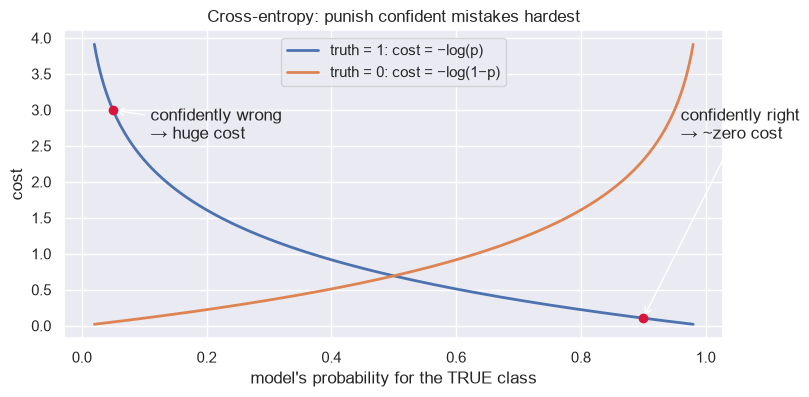

In [5]:
p_line = np.linspace(0.02, 0.98, 300)
plt.figure(figsize=(8.5, 4))
plt.plot(p_line, -np.log(p_line), label="truth = 1: cost = -log(p)", lw=2)
plt.plot(p_line, -np.log(1-p_line), label="truth = 0: cost = -log(1-p)", lw=2)
for p_bad, txt in [(0.05, "confidently wrong\n→ huge cost"), (0.9, "confidently right\n→ ~zero cost")]:
    plt.scatter([p_bad], [-np.log(p_bad)], color="crimson", zorder=5)
    plt.annotate(txt, (p_bad, -np.log(p_bad)), xytext=(p_bad+0.06, 2.6),
                 arrowprops=dict(arrowstyle="->"))
plt.xlabel("model's probability for the TRUE class")
plt.ylabel("cost"); plt.legend(); plt.title("Cross-entropy: punish confident mistakes hardest")
plt.show()

### 6. The gradient - your old friend wearing a new hat

Differentiating cross-entropy through the sigmoid (trust the algebra once) gives
something REMARKABLE:

$$\nabla J = \frac{1}{m}X^T\,(p - y)$$

Compare with linear regression: $\nabla J = \frac{1}{m}X^T(X\theta - y)$.

IDENTICAL SHAPE - "average error times inputs". So gradient descent is literally
the same loop you implemented before:

$$w := w - \alpha \cdot \frac{1}{m}X^T(p-y), \qquad p=\sigma(Xw)$$

That is the entire algorithm. Notebook 02 codes it in ~30 lines.

### When logistic regression is the right tool

| Great fit | Think twice |
|---|---|
| binary/multi-class yes-no problems | complex non-linear boundaries (trees first) |
| need HONEST probabilities (risk scores) | massive feature spaces without regularization |
| interpretability required (medical, credit) | heavy missingness / text-only raw signals |
| fast baseline for any tabular classification | perfectly separable data (weights diverge → use C) |

### Summary & key takeaways

- Log-odds turn probability into "regression land"; the sigmoid brings us back.
- Model: $p=\sigma(Xw)$; decide at $p\ge0.5$ (movable later).
- Cross-entropy loss = punish confident wrong guesses; single elegant formula.
- Gradient $\frac1mX^T(p-y)$ - same skeleton as linear regression's GD.
- Outputs are real PROBABILITIES - that's the superpower we exploit everywhere next.